PORTFOLIO CHECK
Number of securities: 30
Total market value: €76,000,000
Fund NAV: €100,000,000



   Security      Asset_Class             Issuer  Market_Value  Weight  \
0      AAPL           Equity              Apple       4500000   0.045   
1      MSFT           Equity          Microsoft       4000000   0.040   
2      NVDA           Equity             NVIDIA       3800000   0.038   
3      AMZN           Equity             Amazon       3200000   0.032   
4     GOOGL           Equity           Alphabet       3000000   0.030   
5      META           Equity               Meta       2800000   0.028   
6       JPM           Equity           JPMorgan       2500000   0.025   
7         V           Equity               Visa       2500000   0.025   
8       JNJ           Equity  Johnson & Johnson       2300000   0.023   
9        PG           Equity   Procter & Gamble       2200000   0.022   
10       KO           Equity          Coca-Cola       2000000   0.020   
11      XOM           Equ

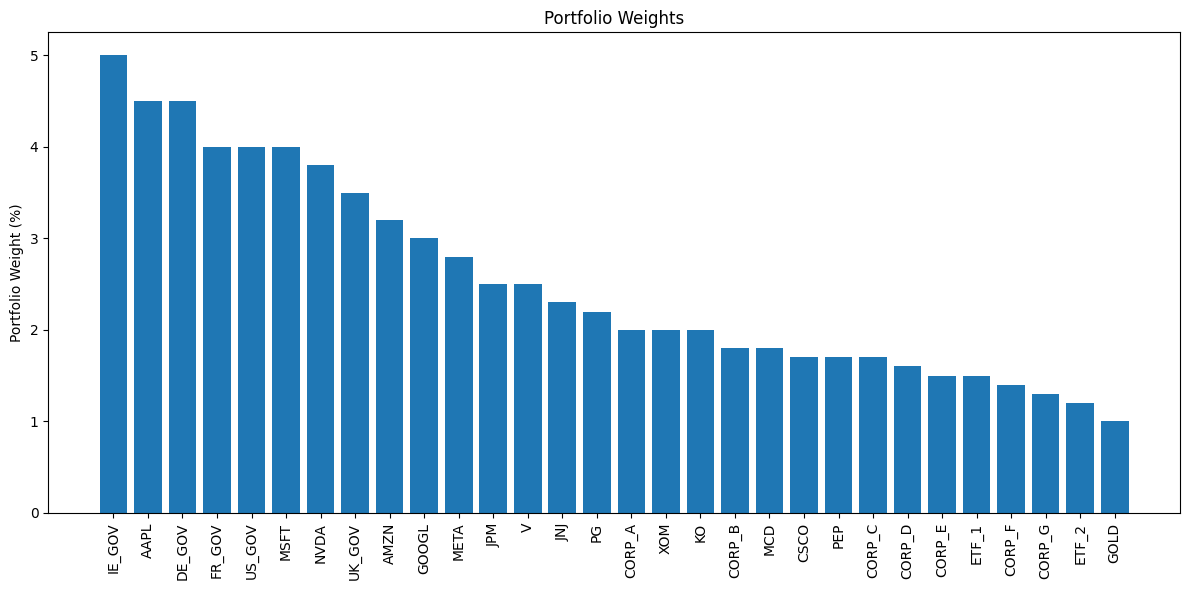

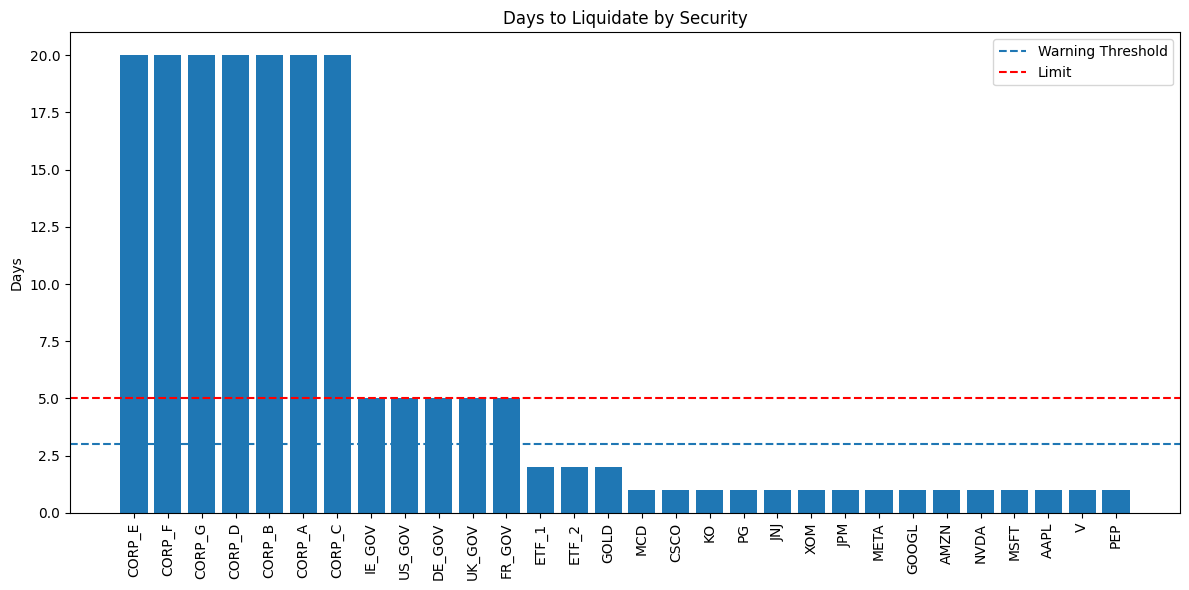

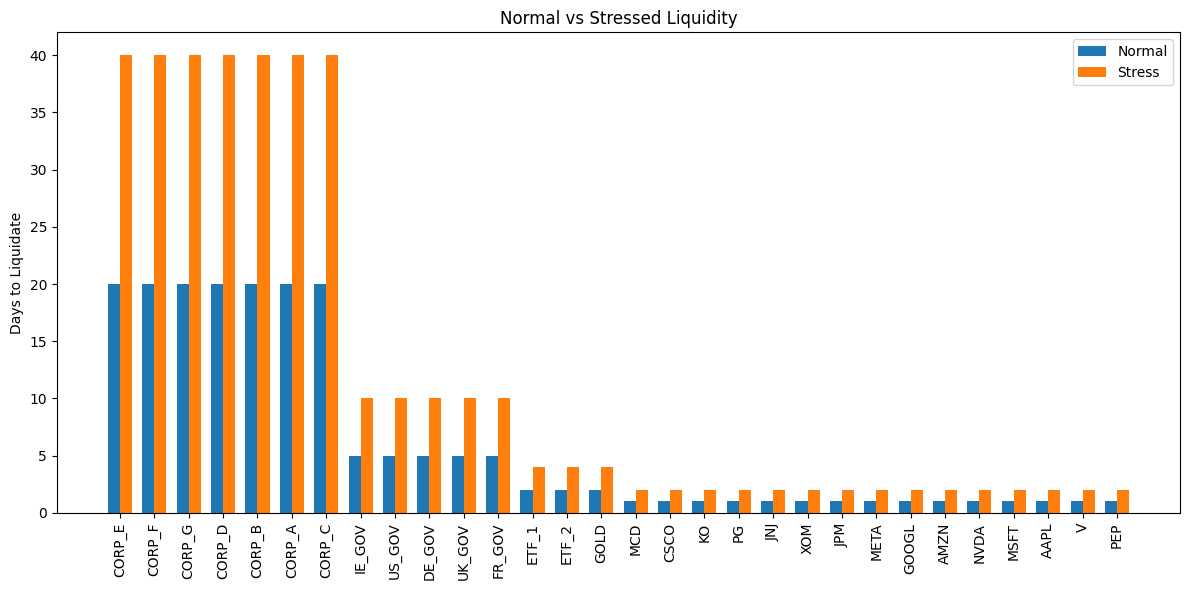



PROJECT COMPLETE

The simulated UCITS-style risk monitoring workflow has completed.

Outputs generated:

1. 30-security portfolio
2. Portfolio weights
3. Historical VaR
4. Parametric VaR
5. Monte Carlo VaR
6. Issuer concentration monitoring
7. Simplified 5/10/40-style checks
8. Days-to-liquidate analysis
9. Liquidity stress testing
10. Redemption stress testing
11. Green/Amber/Red severity
12. Exception report
13. Excel risk report
14. Risk visualizations

OVERALL RISK STATUS: RED


In [2]:

# UCITS-STYLE INVESTMENT RISK MONITORING SIMULATION
# Simulated €100m fund with 30 securities
#
# Modules:
# 1. Portfolio construction
# 2. Historical market data
# 3. Historical VaR
# 4. Parametric VaR
# 5. Monte Carlo VaR
# 6. Issuer concentration
# 7. Liquidity / days-to-liquidate
# 8. Liquidity stress testing
# 9. Redemption stress testing
# 10. Exception & severity engine
# 11. Excel reporting
# 12. Dashboard
#
# NOTE:
# This is a simulated educational project.
# UCITS concentration rules are simplified.
# Liquidity thresholds are internal assumptions, not statutory
# UCITS liquidation limits.

# 1. IMPORT LIBRARIES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

import yfinance as yf

from datetime import datetime


# Reproducibility
np.random.seed(42)



# 2. FUND PARAMETERS


FUND_NAV = 100_000_000       # €100 million fund

CONFIDENCE_95 = 0.95
CONFIDENCE_99 = 0.99

# Internal VaR limits
VAR_95_LIMIT = 2_000_000
VAR_99_LIMIT = 3_000_000

# Simplified concentration thresholds
CONCENTRATION_WARNING = 0.045   # 4.5%
CONCENTRATION_LIMIT = 0.05      # 5%
CONCENTRATION_HARD_LIMIT = 0.10 # 10%
AGGREGATE_40_LIMIT = 0.40        # 40%

# Liquidity assumptions
MAX_PARTICIPATION_RATE = 0.10   # 10% of ADV

# Internal liquidity warning thresholds
LIQUIDITY_WARNING_DAYS = 3
LIQUIDITY_LIMIT_DAYS = 5

# Redemption stress
REDEMPTION_STRESS_PERCENT = 0.20   # 20% redemption

# Liquidity stress assumption
LIQUIDITY_STRESS_FACTOR = 0.50     # ADV falls 50%



# 3. CREATE THE 30-SECURITY PORTFOLIO


portfolio_data = [



    ["AAPL", "Equity", "Apple", 4_500_000],
    ["MSFT", "Equity", "Microsoft", 4_000_000],
    ["NVDA", "Equity", "NVIDIA", 3_800_000],
    ["AMZN", "Equity", "Amazon", 3_200_000],
    ["GOOGL", "Equity", "Alphabet", 3_000_000],
    ["META", "Equity", "Meta", 2_800_000],
    ["JPM", "Equity", "JPMorgan", 2_500_000],
    ["V", "Equity", "Visa", 2_500_000],
    ["JNJ", "Equity", "Johnson & Johnson", 2_300_000],
    ["PG", "Equity", "Procter & Gamble", 2_200_000],
    ["KO", "Equity", "Coca-Cola", 2_000_000],
    ["XOM", "Equity", "Exxon Mobil", 2_000_000],
    ["MCD", "Equity", "McDonald's", 1_800_000],
    ["CSCO", "Equity", "Cisco", 1_700_000],
    ["PEP", "Equity", "PepsiCo", 1_700_000],



    ["IE_GOV", "Government Bond", "Ireland", 5_000_000],
    ["DE_GOV", "Government Bond", "Germany", 4_500_000],
    ["FR_GOV", "Government Bond", "France", 4_000_000],
    ["US_GOV", "Government Bond", "United States", 4_000_000],
    ["UK_GOV", "Government Bond", "United Kingdom", 3_500_000],



    ["CORP_A", "Corporate Bond", "Company A", 2_000_000],
    ["CORP_B", "Corporate Bond", "Company B", 1_800_000],
    ["CORP_C", "Corporate Bond", "Company C", 1_700_000],
    ["CORP_D", "Corporate Bond", "Company D", 1_600_000],
    ["CORP_E", "Corporate Bond", "Company E", 1_500_000],
    ["CORP_F", "Corporate Bond", "Company F", 1_400_000],
    ["CORP_G", "Corporate Bond", "Company G", 1_300_000],



    ["ETF_1", "ETF", "Diversified ETF", 1_500_000],
    ["ETF_2", "ETF", "Bond ETF", 1_200_000],
    ["GOLD", "Commodity", "Gold", 1_000_000],
]



# 4. CREATE DATAFRAME


portfolio = pd.DataFrame(
    portfolio_data,
    columns=[
        "Security",
        "Asset_Class",
        "Issuer",
        "Market_Value"
    ]
)



# 5. CHECK PORTFOLIO


print("=" * 60)
print("PORTFOLIO CHECK")
print("=" * 60)

print(f"Number of securities: {len(portfolio)}")

print(
    f"Total market value: "
    f"€{portfolio['Market_Value'].sum():,.0f}"
)

print(
    f"Fund NAV: "
    f"€{FUND_NAV:,.0f}"
)


# Make sure portfolio equals NAV

if portfolio["Market_Value"].sum() != FUND_NAV:
    print("\nWARNING: Portfolio does not equal fund NAV.")

else:
    print("\nPortfolio reconciles to Fund NAV.")



# 6. CALCULATE PORTFOLIO WEIGHTS


portfolio["Weight"] = (
    portfolio["Market_Value"] / FUND_NAV
)


# Convert to percentage

portfolio["Weight_Pct"] = (
    portfolio["Weight"] * 100
)


print("\n")
print(portfolio)


# 7. CREATE MARKET DATA


equity_tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "JPM",
    "V",
    "JNJ",
    "PG",
    "KO",
    "XOM",
    "MCD",
    "CSCO",
    "PEP"
]


print("\n")
print("=" * 60)
print("DOWNLOADING MARKET DATA")
print("=" * 60)


# Download 3 years of daily prices

prices = yf.download(
    equity_tickers,
    period="3y",
    auto_adjust=True,
    progress=False
)


# yfinance may return multi-index columns

if isinstance(prices.columns, pd.MultiIndex):

    if "Close" in prices.columns.levels[0]:
        prices = prices["Close"]

    elif "Adj Close" in prices.columns.levels[0]:
        prices = prices["Adj Close"]


# Remove missing observations

prices = prices.dropna()


print(
    f"Downloaded {len(prices)} trading days."
)



# 8. CALCULATE DAILY RETURNS


returns = prices.pct_change().dropna()


print("\nDaily returns:")
print(returns.head())



# 9. CREATE EQUITY WEIGHT VECTOR


equity_portfolio = portfolio[
    portfolio["Asset_Class"] == "Equity"
].copy()


equity_weights = (
    equity_portfolio
    .set_index("Security")["Weight"]
)


# Keep only securities available in market data

available_tickers = [
    ticker
    for ticker in equity_weights.index
    if ticker in returns.columns
]


equity_weights = equity_weights[
    available_tickers
]


returns = returns[
    available_tickers
]


# 10. CALCULATE DAILY PORTFOLIO RETURNS


portfolio_daily_returns = (
    returns * equity_weights
).sum(axis=1)


print("\n")
print("=" * 60)
print("PORTFOLIO RETURNS")
print("=" * 60)

print(
    portfolio_daily_returns.describe()
)



# 11. HISTORICAL VaR


historical_var_95 = -np.percentile(
    portfolio_daily_returns,
    5
) * FUND_NAV


historical_var_99 = -np.percentile(
    portfolio_daily_returns,
    1
) * FUND_NAV


print("\n")
print("=" * 60)
print("HISTORICAL VaR")
print("=" * 60)

print(
    f"95% Historical VaR: "
    f"€{historical_var_95:,.0f}"
)

print(
    f"99% Historical VaR: "
    f"€{historical_var_99:,.0f}"
)



# 12. PARAMETRIC VaR


portfolio_mean = portfolio_daily_returns.mean()

portfolio_std = portfolio_daily_returns.std()


z_95 = norm.ppf(0.95)
z_99 = norm.ppf(0.99)


parametric_var_95 = (
    z_95
    * portfolio_std
    * FUND_NAV
)


parametric_var_99 = (
    z_99
    * portfolio_std
    * FUND_NAV
)


print("\n")
print("=" * 60)
print("PARAMETRIC VaR")
print("=" * 60)

print(
    f"Portfolio volatility: "
    f"{portfolio_std:.4%}"
)

print(
    f"95% Parametric VaR: "
    f"€{parametric_var_95:,.0f}"
)

print(
    f"99% Parametric VaR: "
    f"€{parametric_var_99:,.0f}"
)



# 13. MONTE CARLO VaR


NUM_SIMULATIONS = 10_000


# Calculate mean and covariance matrix

mean_returns = returns.mean()

covariance_matrix = returns.cov()


# Generate correlated random returns

simulated_returns = np.random.multivariate_normal(
    mean_returns,
    covariance_matrix,
    NUM_SIMULATIONS
)


# Calculate portfolio return for each simulation

simulation_portfolio_returns = (
    simulated_returns * equity_weights.values
).sum(axis=1)


# Calculate simulated losses

simulation_losses = (
    -simulation_portfolio_returns
    * FUND_NAV
)


monte_carlo_var_95 = np.percentile(
    simulation_losses,
    95
)


monte_carlo_var_99 = np.percentile(
    simulation_losses,
    99
)


print("\n")
print("=" * 60)
print("MONTE CARLO VaR")
print("=" * 60)

print(
    f"Simulations: {NUM_SIMULATIONS:,}"
)

print(
    f"95% Monte Carlo VaR: "
    f"€{monte_carlo_var_95:,.0f}"
)

print(
    f"99% Monte Carlo VaR: "
    f"€{monte_carlo_var_99:,.0f}"
)



# 14. VaR LIMIT CHECK


def var_status(var_value, limit):

    if var_value > limit:
        return "RED"

    elif var_value > limit * 0.90:
        return "AMBER"

    else:
        return "GREEN"


var_95_status = var_status(
    historical_var_95,
    VAR_95_LIMIT
)


var_99_status = var_status(
    historical_var_99,
    VAR_99_LIMIT
)


print("\n")
print("=" * 60)
print("VaR LIMIT MONITORING")
print("=" * 60)

print(
    f"95% VaR status: {var_95_status}"
)

print(
    f"99% VaR status: {var_99_status}"
)



# 15. ISSUER CONCENTRATION


issuer_exposure = (
    portfolio
    .groupby("Issuer")["Market_Value"]
    .sum()
    .reset_index()
)


issuer_exposure["Issuer_Weight"] = (
    issuer_exposure["Market_Value"]
    / FUND_NAV
)


issuer_exposure["Issuer_Weight_Pct"] = (
    issuer_exposure["Issuer_Weight"]
    * 100
)


# Flag issuers above 5%

issuer_exposure["Above_5pct"] = (
    issuer_exposure["Issuer_Weight"]
    > CONCENTRATION_LIMIT
)


# Flag issuers above 10%

issuer_exposure["Above_10pct"] = (
    issuer_exposure["Issuer_Weight"]
    > CONCENTRATION_HARD_LIMIT
)


print("\n")
print("=" * 60)
print("ISSUER CONCENTRATION")
print("=" * 60)

print(
    issuer_exposure
    .sort_values(
        "Issuer_Weight",
        ascending=False
    )
)



# 16. 40% AGGREGATE CHECK


aggregate_over_5 = issuer_exposure.loc[
    issuer_exposure["Issuer_Weight"]
    > CONCENTRATION_LIMIT,
    "Issuer_Weight"
].sum()


aggregate_over_5_pct = (
    aggregate_over_5 * 100
)


if aggregate_over_5 > AGGREGATE_40_LIMIT:
    aggregate_40_status = "RED"

elif aggregate_over_5 > 0.90 * AGGREGATE_40_LIMIT:
    aggregate_40_status = "AMBER"

else:
    aggregate_40_status = "GREEN"


print("\n")
print(
    f"Aggregate exposure to issuers >5%: "
    f"{aggregate_over_5_pct:.2f}%"
)

print(
    f"40% status: {aggregate_40_status}"
)



# 17. CONCENTRATION EXCEPTIONS


concentration_exceptions = issuer_exposure[
    issuer_exposure["Above_5pct"]
].copy()


print("\n")
print("=" * 60)
print("CONCENTRATION EXCEPTIONS")
print("=" * 60)

print(
    concentration_exceptions[
        [
            "Issuer",
            "Issuer_Weight_Pct",
            "Above_5pct",
            "Above_10pct"
        ]
    ]
)



# 18. CREATE LIQUIDITY DATA


# For this simulated project:
#
# Equities:
# approximate ADV using median daily trading value
#
# Bonds / other assets:
# use simulated ADV assumptions


liquidity_data = []


# Equity liquidity

for ticker in equity_portfolio["Security"]:

    if ticker in prices.columns:

        # Simulated approximate ADV
        # based on market activity.
        #
        # This is NOT intended to represent actual
        # fund trading capacity.

        position = equity_portfolio.loc[
            equity_portfolio["Security"] == ticker,
            "Market_Value"
        ].iloc[0]

        # Create reasonable simulated ADV
        adv = max(
            position * 10,
            5_000_000
        )

        liquidity_data.append(
            [ticker, adv]
        )


# Government bonds

government_bonds = portfolio[
    portfolio["Asset_Class"] == "Government Bond"
]


for _, row in government_bonds.iterrows():

    adv = row["Market_Value"] * 2

    liquidity_data.append(
        [row["Security"], adv]
    )


# Corporate bonds

corporate_bonds = portfolio[
    portfolio["Asset_Class"] == "Corporate Bond"
]


for _, row in corporate_bonds.iterrows():

    adv = row["Market_Value"] * 0.50

    liquidity_data.append(
        [row["Security"], adv]
    )


# Other assets

other_assets = portfolio[
    portfolio["Asset_Class"].isin(
        ["ETF", "Commodity"]
    )
]


for _, row in other_assets.iterrows():

    adv = row["Market_Value"] * 5

    liquidity_data.append(
        [row["Security"], adv]
    )


liquidity_df = pd.DataFrame(
    liquidity_data,
    columns=[
        "Security",
        "ADV"
    ]
)


# Merge with portfolio

portfolio = portfolio.merge(
    liquidity_df,
    on="Security",
    how="left"
)



# 19. CALCULATE LIQUIDATION CAPACITY


portfolio["Daily_Liquidation_Capacity"] = (
    portfolio["ADV"]
    * MAX_PARTICIPATION_RATE
)



# 20. DAYS TO LIQUIDATE


portfolio["Days_To_Liquidate"] = (
    portfolio["Market_Value"]
    /
    portfolio["Daily_Liquidation_Capacity"]
)


print("\n")
print("=" * 60)
print("LIQUIDITY ANALYSIS")
print("=" * 60)

print(
    portfolio[
        [
            "Security",
            "Market_Value",
            "ADV",
            "Daily_Liquidation_Capacity",
            "Days_To_Liquidate"
        ]
    ]
    .sort_values(
        "Days_To_Liquidate",
        ascending=False
    )
)



# 21. LIQUIDITY CLASSIFICATION


def liquidity_bucket(days):

    if days <= 1:
        return "Very Liquid"

    elif days <= 3:
        return "Liquid"

    elif days <= 5:
        return "Moderate"

    elif days <= 10:
        return "Illiquid"

    else:
        return "Highly Illiquid"


portfolio["Liquidity_Bucket"] = (
    portfolio["Days_To_Liquidate"]
    .apply(liquidity_bucket)
)



# 22. LIQUIDITY STATUS


def liquidity_status(days):

    if days > LIQUIDITY_LIMIT_DAYS:
        return "RED"

    elif days > LIQUIDITY_WARNING_DAYS:
        return "AMBER"

    else:
        return "GREEN"


portfolio["Liquidity_Status"] = (
    portfolio["Days_To_Liquidate"]
    .apply(liquidity_status)
)



# 23. LIQUIDITY STRESS TEST


portfolio["Stressed_ADV"] = (
    portfolio["ADV"]
    * LIQUIDITY_STRESS_FACTOR
)


portfolio["Stressed_Daily_Capacity"] = (
    portfolio["Stressed_ADV"]
    * MAX_PARTICIPATION_RATE
)


portfolio["Stressed_Days_To_Liquidate"] = (
    portfolio["Market_Value"]
    /
    portfolio["Stressed_Daily_Capacity"]
)


portfolio["Stress_Liquidity_Bucket"] = (
    portfolio["Stressed_Days_To_Liquidate"]
    .apply(liquidity_bucket)
)


print("\n")
print("=" * 60)
print("LIQUIDITY STRESS TEST")
print("=" * 60)

print(
    portfolio[
        [
            "Security",
            "Days_To_Liquidate",
            "Stressed_Days_To_Liquidate"
        ]
    ]
    .sort_values(
        "Stressed_Days_To_Liquidate",
        ascending=False
    )
)



# 24. REDEMPTION STRESS TEST


redemption_amount = (
    FUND_NAV
    * REDEMPTION_STRESS_PERCENT
)


print("\n")
print("=" * 60)
print("REDEMPTION STRESS TEST")
print("=" * 60)

print(
    f"Fund NAV: €{FUND_NAV:,.0f}"
)

print(
    f"Stress redemption: "
    f"{REDEMPTION_STRESS_PERCENT:.0%}"
)

print(
    f"Redemption amount: "
    f"€{redemption_amount:,.0f}"
)


# Calculate amount liquidatable within
# different time horizons

horizons = [1, 3, 5, 10]

redemption_results = []


for days in horizons:

    # Under normal liquidity

    liquidatable_normal = np.minimum(
        portfolio["Market_Value"],
        portfolio["Daily_Liquidation_Capacity"]
        * days
    ).sum()


    # Under stressed liquidity

    liquidatable_stress = np.minimum(
        portfolio["Market_Value"],
        portfolio["Stressed_Daily_Capacity"]
        * days
    ).sum()


    redemption_results.append(
        [
            days,
            liquidatable_normal,
            liquidatable_stress,
            liquidatable_normal >= redemption_amount,
            liquidatable_stress >= redemption_amount
        ]
    )


redemption_df = pd.DataFrame(
    redemption_results,
    columns=[
        "Horizon_Days",
        "Normal_Liquidatable",
        "Stress_Liquidatable",
        "Normal_Covered",
        "Stress_Covered"
    ]
)


print("\n")
print(redemption_df)



# 25. FIND FIRST STRESSED COVERAGE HORIZON


stress_coverage = redemption_df[
    redemption_df["Stress_Covered"]
]


if len(stress_coverage) > 0:

    stressed_coverage_days = (
        stress_coverage["Horizon_Days"]
        .iloc[0]
    )

else:

    stressed_coverage_days = np.nan


print(
    f"\nStressed redemption coverage: "
    f"{stressed_coverage_days} days"
)



# 26. BUILD EXCEPTION REPORT


exceptions = []



# VaR exceptions


if historical_var_95 > VAR_95_LIMIT:

    exceptions.append(
        [
            "Market Risk",
            "95% Historical VaR",
            historical_var_95,
            VAR_95_LIMIT,
            "RED",
            "Escalate to Risk Manager"
        ]
    )

elif historical_var_95 > VAR_95_LIMIT * 0.90:

    exceptions.append(
        [
            "Market Risk",
            "95% Historical VaR",
            historical_var_95,
            VAR_95_LIMIT,
            "AMBER",
            "Review risk level"
        ]
    )


if historical_var_99 > VAR_99_LIMIT:

    exceptions.append(
        [
            "Market Risk",
            "99% Historical VaR",
            historical_var_99,
            VAR_99_LIMIT,
            "RED",
            "Escalate to Risk Manager"
        ]
    )

elif historical_var_99 > VAR_99_LIMIT * 0.90:

    exceptions.append(
        [
            "Market Risk",
            "99% Historical VaR",
            historical_var_99,
            VAR_99_LIMIT,
            "AMBER",
            "Review risk level"
        ]
    )



# Concentration exceptions


for _, row in issuer_exposure.iterrows():

    exposure = row["Issuer_Weight"]

    if exposure > CONCENTRATION_HARD_LIMIT:

        exceptions.append(
            [
                "Concentration Risk",
                f"{row['Issuer']} exposure",
                exposure,
                CONCENTRATION_HARD_LIMIT,
                "RED",
                "Escalate concentration breach"
            ]
        )

    elif exposure > CONCENTRATION_LIMIT:

        exceptions.append(
            [
                "Concentration Risk",
                f"{row['Issuer']} exposure",
                exposure,
                CONCENTRATION_LIMIT,
                "AMBER",
                "Review issuer exposure"
            ]
        )



# Aggregate 40% exception


if aggregate_over_5 > AGGREGATE_40_LIMIT:

    exceptions.append(
        [
            "Concentration Risk",
            "Aggregate >5% exposure",
            aggregate_over_5,
            AGGREGATE_40_LIMIT,
            "RED",
            "Escalate concentration breach"
        ]
    )


elif aggregate_over_5 > 0.90 * AGGREGATE_40_LIMIT:

    exceptions.append(
        [
            "Concentration Risk",
            "Aggregate >5% exposure",
            aggregate_over_5,
            AGGREGATE_40_LIMIT,
            "AMBER",
            "Review aggregate exposure"
        ]
    )



# Liquidity exceptions


for _, row in portfolio.iterrows():

    days = row["Days_To_Liquidate"]

    if days > LIQUIDITY_LIMIT_DAYS:

        exceptions.append(
            [
                "Liquidity Risk",
                f"{row['Security']} liquidation",
                days,
                LIQUIDITY_LIMIT_DAYS,
                "RED",
                "Escalate liquidity concern"
            ]
        )

    elif days > LIQUIDITY_WARNING_DAYS:

        exceptions.append(
            [
                "Liquidity Risk",
                f"{row['Security']} liquidation",
                days,
                LIQUIDITY_WARNING_DAYS,
                "AMBER",
                "Review liquidity"
            ]
        )


# Redemption stress exception


if stressed_coverage_days > 5 or np.isnan(
    stressed_coverage_days
):

    exceptions.append(
        [
            "Liquidity Stress",
            "20% redemption coverage",
            stressed_coverage_days,
            5,
            "RED",
            "Escalate liquidity stress"
        ]
    )


elif stressed_coverage_days > 3:

    exceptions.append(
        [
            "Liquidity Stress",
            "20% redemption coverage",
            stressed_coverage_days,
            3,
            "AMBER",
            "Review redemption liquidity"
        ]
    )



# 27. CREATE EXCEPTION DATAFRAME


exceptions_df = pd.DataFrame(
    exceptions,
    columns=[
        "Risk_Type",
        "Metric",
        "Actual",
        "Threshold",
        "Severity",
        "Action"
    ]
)


print("\n")
print("=" * 60)
print("EXCEPTION REPORT")
print("=" * 60)

if len(exceptions_df) == 0:

    print("No exceptions identified.")

else:

    print(exceptions_df)



# 28. OVERALL RISK STATUS


if len(exceptions_df) == 0:

    overall_status = "GREEN"

elif "RED" in exceptions_df["Severity"].values:

    overall_status = "RED"

else:

    overall_status = "AMBER"



# 29. DAILY RISK SUMMARY


print("\n")
print("=" * 60)
print("DAILY FUND RISK REPORT")
print("=" * 60)

print(
    f"Report date: {datetime.today().strftime('%Y-%m-%d')}"
)

print(
    f"Fund NAV: €{FUND_NAV:,.0f}"
)

print("\nMARKET RISK")
print(
    f"95% Historical VaR: "
    f"€{historical_var_95:,.0f}"
)

print(
    f"99% Historical VaR: "
    f"€{historical_var_99:,.0f}"
)

print(
    f"95% Parametric VaR: "
    f"€{parametric_var_95:,.0f}"
)

print(
    f"99% Parametric VaR: "
    f"€{parametric_var_99:,.0f}"
)

print(
    f"95% Monte Carlo VaR: "
    f"€{monte_carlo_var_95:,.0f}"
)

print(
    f"99% Monte Carlo VaR: "
    f"€{monte_carlo_var_99:,.0f}"
)


print("\nCONCENTRATION RISK")

print(
    f"Number of issuers >5%: "
    f"{(issuer_exposure['Above_5pct']).sum()}"
)

print(
    f"Aggregate >5% exposure: "
    f"{aggregate_over_5_pct:.2f}%"
)

print(
    f"40% check: "
    f"{aggregate_40_status}"
)


print("\nLIQUIDITY RISK")

print(
    f"Maximum days-to-liquidate: "
    f"{portfolio['Days_To_Liquidate'].max():.2f}"
)

print(
    f"Maximum stressed days-to-liquidate: "
    f"{portfolio['Stressed_Days_To_Liquidate'].max():.2f}"
)


print("\nREDEMPTION STRESS")

print(
    f"20% redemption: "
    f"€{redemption_amount:,.0f}"
)

print(
    f"Stressed coverage horizon: "
    f"{stressed_coverage_days} days"
)


print("\nEXCEPTIONS")

print(
    f"Total exceptions: "
    f"{len(exceptions_df)}"
)

if len(exceptions_df) > 0:

    print(
        f"RED exceptions: "
        f"{(exceptions_df['Severity'] == 'RED').sum()}"
    )

    print(
        f"AMBER exceptions: "
        f"{(exceptions_df['Severity'] == 'AMBER').sum()}"
    )


print("\n")
print(
    f"OVERALL FUND RISK STATUS: "
    f"{overall_status}"
)



# 30. EXPORT TO EXCEL


output_file = "UCITS_Risk_Monitoring.xlsx"


with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Portfolio
    portfolio.to_excel(
        writer,
        sheet_name="Portfolio",
        index=False
    )

    # Issuer concentration
    issuer_exposure.to_excel(
        writer,
        sheet_name="Concentration",
        index=False
    )

    # Returns
    returns.to_excel(
        writer,
        sheet_name="Market_Returns"
    )

    # Redemption stress
    redemption_df.to_excel(
        writer,
        sheet_name="Redemption_Stress",
        index=False
    )

    # Exceptions
    exceptions_df.to_excel(
        writer,
        sheet_name="Exceptions",
        index=False
    )

    # VaR summary
    var_summary = pd.DataFrame({
        "Metric": [
            "Historical VaR 95%",
            "Historical VaR 99%",
            "Parametric VaR 95%",
            "Parametric VaR 99%",
            "Monte Carlo VaR 95%",
            "Monte Carlo VaR 99%"
        ],

        "Value": [
            historical_var_95,
            historical_var_99,
            parametric_var_95,
            parametric_var_99,
            monte_carlo_var_95,
            monte_carlo_var_99
        ]
    })

    var_summary.to_excel(
        writer,
        sheet_name="VaR",
        index=False
    )


print("\n")
print("=" * 60)
print("EXCEL EXPORT")
print("=" * 60)

print(
    f"File created: {output_file}"
)



# 31. VISUALIZATION 1 — PORTFOLIO WEIGHTS


plt.figure(figsize=(12, 6))

portfolio_sorted = portfolio.sort_values(
    "Weight_Pct",
    ascending=False
)

plt.bar(
    portfolio_sorted["Security"],
    portfolio_sorted["Weight_Pct"]
)

plt.xticks(
    rotation=90
)

plt.ylabel("Portfolio Weight (%)")
plt.title("Portfolio Weights")

plt.tight_layout()

plt.show()



# 32. VISUALIZATION 2 — DAYS TO LIQUIDATE


plt.figure(figsize=(12, 6))

liquidity_sorted = portfolio.sort_values(
    "Days_To_Liquidate",
    ascending=False
)

plt.bar(
    liquidity_sorted["Security"],
    liquidity_sorted["Days_To_Liquidate"]
)

plt.axhline(
    LIQUIDITY_WARNING_DAYS,
    linestyle="--",
    label="Warning Threshold"
)

plt.axhline(
    LIQUIDITY_LIMIT_DAYS,
    linestyle="--",
    color="red",
    label="Limit"
)

plt.xticks(
    rotation=90
)

plt.ylabel("Days")
plt.title("Days to Liquidate by Security")

plt.legend()

plt.tight_layout()

plt.show()



# 33. VISUALIZATION 3 — NORMAL VS STRESSED LIQUIDITY


plt.figure(figsize=(12, 6))

comparison = portfolio.sort_values(
    "Days_To_Liquidate",
    ascending=False
)

x = np.arange(
    len(comparison)
)

width = 0.35

plt.bar(
    x - width / 2,
    comparison["Days_To_Liquidate"],
    width,
    label="Normal"
)

plt.bar(
    x + width / 2,
    comparison["Stressed_Days_To_Liquidate"],
    width,
    label="Stress"
)

plt.xticks(
    x,
    comparison["Security"],
    rotation=90
)

plt.ylabel("Days to Liquidate")
plt.title("Normal vs Stressed Liquidity")

plt.legend()

plt.tight_layout()

plt.show()



# 34. FINAL OUTPUT


print("\n")
print("=" * 60)
print("PROJECT COMPLETE")
print("=" * 60)

print("""
The simulated UCITS-style risk monitoring workflow has completed.

Outputs generated:

1. 30-security portfolio
2. Portfolio weights
3. Historical VaR
4. Parametric VaR
5. Monte Carlo VaR
6. Issuer concentration monitoring
7. Simplified 5/10/40-style checks
8. Days-to-liquidate analysis
9. Liquidity stress testing
10. Redemption stress testing
11. Green/Amber/Red severity
12. Exception report
13. Excel risk report
14. Risk visualizations
""")

print(
    f"OVERALL RISK STATUS: {overall_status}"
)